# Euroleague Spatial Analytics & Shot Selection Profile

**Data Engineer/Analyst:** Nicolas Andrianopoulos 
**Target Player:** Tyler Dorsey

### Project Overview
This notebook extracts, calibrates and analyzes spatial shooting data from the 
**official Euroleague API**.The goal is to build a high-fidelity visual profile of 
a player's shot selection using advanced spatial filtering & distribution plots.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import requests
import json
import pandas as pd

gamecode = 355
seasoncode = "E2025"

url = f"https://live.euroleague.net/api/Points?gamecode={gamecode}&seasoncode={seasoncode}"
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(url, headers=headers)
data = response.json()

print("JSON Keys:", data.keys())

print(json.dumps(data, indent=2)[:500])

JSON Keys: dict_keys(['Rows'])
{
  "Rows": [
    {
      "NUM_ANOT": 12,
      "TEAM": "MAD       ",
      "ID_PLAYER": "P005928   ",
      "PLAYER": "CAMPAZZO, FACUNDO",
      "ID_ACTION": "2FGA",
      "ACTION": "Missed Two Pointer",
      "POINTS": 0,
      "COORD_X": -163,
      "COORD_Y": 213,
      "ZONE": "D",
      "FASTBREAK": "0",
      "SECOND_CHANCE": "0",
      "POINTS_OFF_TURNOVER": "0",
      "MINUTE": 1,
      "CONSOLE": "09:48",
      "POINTS_A": 0,
      "POINTS_B": 0,
      "UTC": "20260407181602"
    },
  


In [2]:
df_shots = pd.DataFrame(data["Rows"])
#whitespace cleaning
df_shots['TEAM'] = df_shots['TEAM'].str.strip()
df_shots['PLAYER'] = df_shots['PLAYER'].str.strip()

df_shots[['PLAYER', 'TEAM', 'ACTION', 'ID_ACTION', 'COORD_X', 'COORD_Y']].head()

,PLAYER,TEAM,ACTION,ID_ACTION,COORD_X,COORD_Y
0,"CAMPAZZO, FACUNDO",MAD,Missed Two Pointer,2FGA,-163,213
1,"DORSEY, TYLER",OLY,Three Pointer,3FGM,-6,734
2,"TAVARES, WALTER",MAD,Two Pointer,2FGM,112,25
3,"VEZENKOV, SASHA",OLY,Free Throw In,FTM,-1,-1
4,"VEZENKOV, SASHA",OLY,Free Throw In,FTM,-1,-1


In [3]:
#choose a player that participated in the game
pl_name = "DORSEY, TYLER"
pl_shots = df_shots[df_shots['PLAYER']==pl_name]

if pl_shots.empty:
    print(f"The athlete '{pl_name}' didn't take a shot or didn't participate in the game")
    print("See who participated:")
    available_players = sorted(df_shots['PLAYER'].unique())
    for i in available_players:
        print(i)
else:
    print(f"{len(pl_shots)} were taken by {pl_name}")
    display(pl_shots[['MINUTE', 'ACTION', 'ID_ACTION', 'COORD_X', 'COORD_Y']])


26 were taken by DORSEY, TYLER


,MINUTE,ACTION,ID_ACTION,COORD_X,COORD_Y
1,1,Three Pointer,3FGM,-6,734
14,5,Free Throw In,FTM,-1,-1
21,6,Three Pointer,3FGM,326,677
25,7,Three Pointer,3FGM,-539,483
26,7,Three Pointer,3FGM,-526,658
32,9,Missed Three Pointer,3FGA,169,746
36,10,Missed Three Pointer,3FGA,-589,439
76,20,Two Pointer,2FGM,181,288
81,20,Two Pointer,2FGM,150,345
86,21,Missed Three Pointer,3FGA,181,752


## 1. Spatial Calibration % Vertical Shot Chart

Because the raw data from the Euroleague API coordinate system has a distinct offset for the rim
relative to the baseline, a **calibration of Y-80** was applied to the dataset.
This shift perfectly aligns the shot coordinates with the FIBA vertical half- layout.

* **Green Circles (O):** Made Shots
* **Red Crosses (X):** Missed Shots

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc, Circle

def halfcourt(ax=None, color='black', lw=2):
    '''
        Initializing a function called halfcourt to demonstrate the shot chart as displayed on a basketball halfcourt.
        Since the player duirng the game took shot on both sides of the floor, the 2nd half shots have been inverted.
    '''
    if ax is None:
        ax = plt.gca()
    '''
        Vertical Half Court
        Length (X) between -600 and 600 | Width (Y) between 0 and 800
        Y=0: Baseline | Y=800: Center-court
    '''
    court = Rectangle((-600,0), 1200, 800, linewidth=lw, edgecolor=color, facecolor='none')
    ax.add_patch(court)

    #Rim
    rimx, rimy = 0, 75
    rim = Circle((rimx, rimy), 25, linewidth=lw, edgecolor=color, facecolor='none')
    ax.add_patch(rim)

    #Backboard
    ax.plot([-90, 90], [50,50], color=color, linewidth=lw)

    #Paint
    paint = Rectangle((-240, 0), 480, 490, linewidth=lw, edgecolor=color, facecolor='none')
    ax.add_patch(paint)

    #Three-point line
    ax.plot([-530, -530], [0, 210], color=color, linewidth=lw)
    ax.plot([530, 530], [0, 210], color=color, linewidth=lw)

    #Arc
    arc = Arc((rimx, rimy), 1090, 1090, theta1=12, theta2=168, linewidth=lw, edgecolor=color, facecolor='none')
    ax.add_patch(arc)

    #Center-circle
    center_circle = Arc((0, 800), 240, 240, theta1=180, theta2=360, linewidth=lw, edgecolor=color, facecolor='none')
    ax.add_patch(center_circle)

    return ax

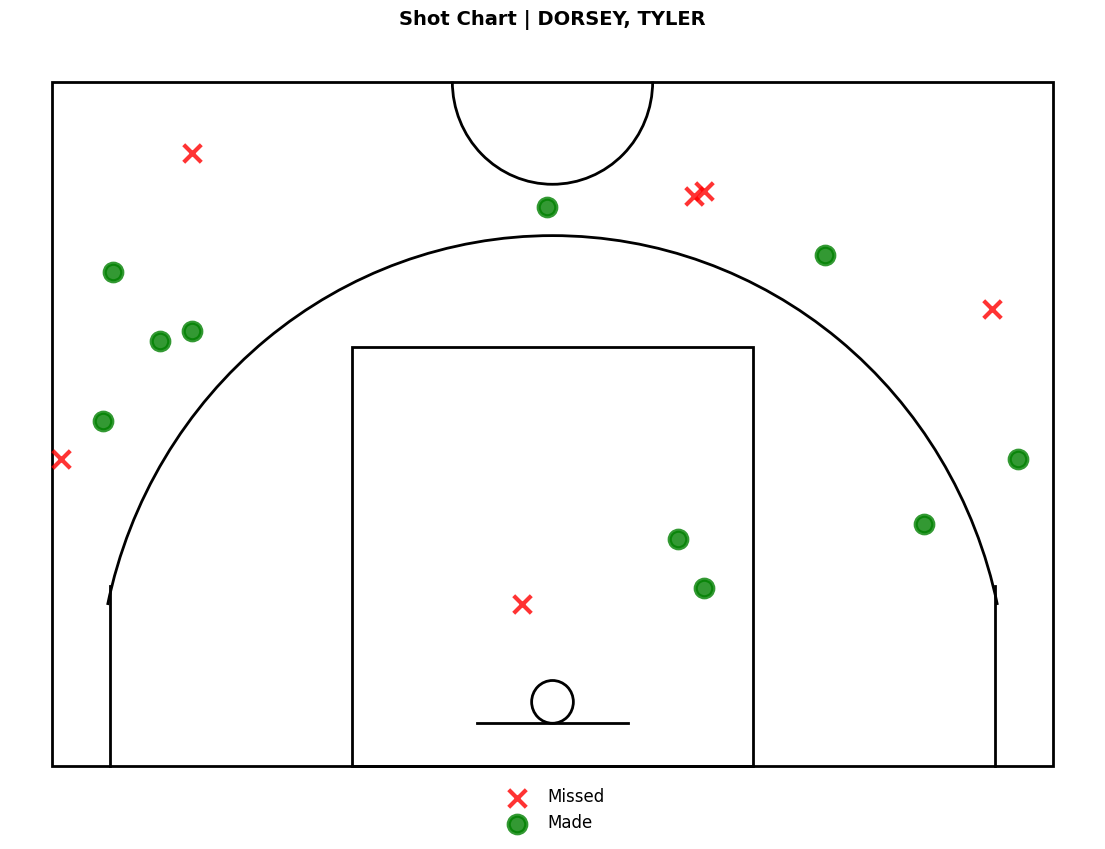

In [5]:
fig, ax = plt.subplots(figsize=(14,10), facecolor='white')
halfcourt(ax,color='black', lw=2)

made_shots = pl_shots[pl_shots["ID_ACTION"].str.endswith('M')]
missed_shots = pl_shots[pl_shots["ID_ACTION"].str.endswith('A')]

#Plotting missed shots
plt.scatter(missed_shots["COORD_X"], missed_shots["COORD_Y"]-80, color='red', label='Missed', alpha=0.8, s=160, marker='x', linewidth=3)

#Plotting made shots
plt.scatter(made_shots["COORD_X"], made_shots["COORD_Y"]-80, color='green', label='Made', alpha=0.8, s=160, marker='o', linewidth=3)

'''
    Notice: Added an offset on the Y coordinates (COORD_Y) to shift the data-points closer to the actual shots took on the court
'''

plt.xlim(-650, 650)
plt.ylim(-50, 850)
plt.axis('off')

plt.title(f"Shot Chart | {pl_name}", fontsize=14, fontweight='bold', pad=10)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.05), fontsize=12, frameon=False)
plt.savefig('shot-chart.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Shot Distance Distribution (Violin Plot)

To analyze the player's **shot selection**, I converted the raw coordinate distances into **meters (m)** using the factor of the FIBA 6.75 three-point line.

The violin plot visualizes the densit of attempts, clearly seperating low-range finishing (0-1.5m) from long-range threats(6.5+m).

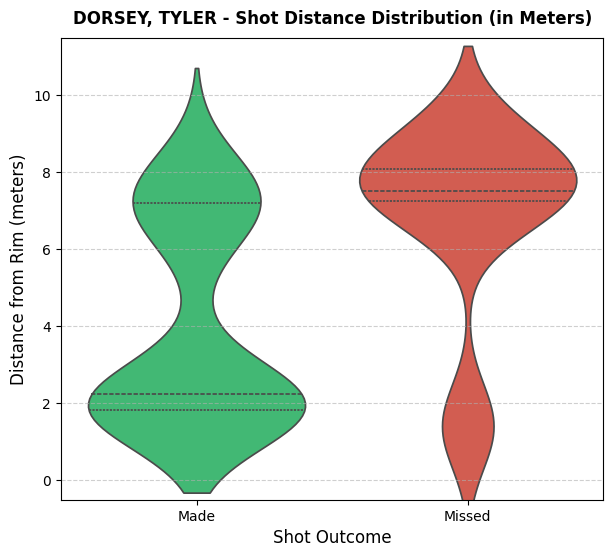

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# counting distance in Units, taking into account: -80 offset and the rim at Y=75)
units = np.sqrt(pl_shots['COORD_X']**2 + (pl_shots['COORD_Y'] - 155)**2)

# turning unites into meters dividing 85
pl_shots['DISTANCE_METERS'] = units / 85.0

pl_shots['Result'] = pl_shots['ID_ACTION'].apply(lambda x: 'Made' if x.endswith('M') else 'Missed')


plt.figure(figsize=(7, 6), facecolor='white')

sns.violinplot(
    data=pl_shots, 
    x='Result', 
    y='DISTANCE_METERS', 
    palette={'Made': '#2ecc71', 'Missed': '#e74c3c'},
    inner='quartile', 
    bw_method=0.4
)

plt.title(f"{pl_name} - Shot Distance Distribution (in Meters)", fontweight='bold', pad=10)
plt.xlabel("Shot Outcome", fontsize=12)
plt.ylabel("Distance from Rim (meters)", fontsize=12)

# limits from 0 to 11.5 meters
plt.ylim(-0.5, 11.5) 
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('violin_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Dynamic Efficiency Metrics Glossary & Interpretation

This section dynamically calculates advanced basketball efficiency metrics to provide a deeper understanding of the player's offensive impact:

* **Effective Field Goal Percentage (eFG%):** Adjusts traditional field goal percentage by accounting for the fact that a 3-point field goal is worth 1.5 times more than a 2-point field goal. A significant positive gap between eFG% and Traditional FG%` highlights high-value perimeter spacing threats.
* **True Shooting Percentage (TS%):** The ultimate efficiency metric. It measures a player's efficiency at producing points from all shooting situations, including Field Goals and Free Throws. In European basketball, a TS% above **60%** is considered elite.
* **Analytical Value:** By focusing on eFG% and TS%, this report strips away volume bias, highlighting whether a player's shot profile maximizes team possessions or introduces scoring inefficiencies.

In [7]:
player_stats = pl_shots[pl_shots['PLAYER'] == pl_name]

# counting how many times each action has happened and putting it in a dictionary
counts = player_stats['ID_ACTION'].value_counts().to_dict()
'''
    counting the sums of each shot/action 
    .get(key, 0) returns 0 if the action didn't happen
    action didn't happen = the player didn't take or make a 2-point, 3-point or Free Throw shot
'''
total_3pm = counts.get('3FGM', 0)
total_3pa = total_3pm + counts.get('3FGA', 0)

total_2pm = counts.get('2FGM', 0)
total_2pa = total_2pm + counts.get('2FGA', 0)

total_ftm = counts.get('FTM', 0)
# Sum of made and missed shots to count the amount of free throws.
total_fta = total_ftm + counts.get('FTA', 0)
fgm = total_3pm + total_2pm
fga = total_3pa + total_2pa

total_points = (total_2pm * 2) + (total_3pm * 3) + (total_ftm * 1)

#eFG% & TS%
if fga > 0:
    traditional_fg_pct = (fgm / fga) * 100
    efg_pct = ((fgm + 0.5 * total_3pm) / fga) * 100
else:
    traditional_fg_pct = efg_pct = 0

#True Shooting (TS%)
if (fga + total_fta) > 0:
    ts_pct = (total_points / (2 * (fga + 0.44 * total_fta))) * 100
else:
    ts_pct = 0

#Free Throw percentage
ft_pct = (total_ftm / total_fta * 100) if total_fta > 0 else 0.0

print("\n")
print(f"ULTIMATE ANALYTICS REPORT: {pl_name.upper()} ")
print("\n")
print(f"Shooting Line (FGM/FGA):         {fgm}/{fga}")
print(f"2-Pointers (Made/Attempts):      {total_2pm}/{total_2pa}")
print(f"3-Pointers (Made/Attempts):      {total_3pm}/{total_3pa}")
print(f"Free Throws (FTM/FTA):           {total_ftm}/{total_fta} ({ft_pct:.1f}%)")
print(f"TOTAL POINTS SCORED:             {total_points} pts")
print("\n")
print("EFFICIENCY & TRUE SHOOTING METRICS:")
print(f"Traditional FG%:                 {traditional_fg_pct:.1f}%")
print(f"Effective FG% (eFG%):            {efg_pct:.1f}%")
print(f"True Shooting% (TS%):            {ts_pct:.1f}%")



ULTIMATE ANALYTICS REPORT: DORSEY, TYLER 


Shooting Line (FGM/FGA):         10/16
2-Pointers (Made/Attempts):      3/4
3-Pointers (Made/Attempts):      7/12
Free Throws (FTM/FTA):           10/10 (100.0%)
TOTAL POINTS SCORED:             37 pts


EFFICIENCY & TRUE SHOOTING METRICS:
Traditional FG%:                 62.5%
Effective FG% (eFG%):            84.4%
True Shooting% (TS%):            90.7%
